# Project report
# CPSC 322 – Fall 2025
# Movie Genre Classification
# Yusen Xia, Sean Pierce

# 1. Introduction

For our project, we use the TMDB 5000 Movies dataset to check if movie genres can be predicted using only **numeric features**

We keep the simple and important numerical columns:

- **budget**
- **popularity**
- **vote_average**
- **vote_count**
- **runtime**
- **release_date** → we changed this to **release_year**
- **genres** → we changed to our three mian genres: **Action / Comedy / Drama**

We implemented this classifiers:

- **Decision Tree**
- **K-NN**
- **NaiveBayes**
- **Random Forest**  

We compared these classifiers and find out that **KNN** have the best performance

# 2. Data Analysis

### 2.1 Dataset Description

**Dataset link:**  
https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata  

**Format:** CSV  
**Size:** Around 5,000 movies

### Dataset Contents

Columns in the dataset include:

- **budget**  
- **genres**  
- **homepage**  
- **id**  
- **keywords**  
- **original_language**  
- **original_title**  
- **overview**  
- **popularity**  
- **production_companies**  
- **production_countries**  
- **release_date**  
- **revenue**  
- **runtime**  
- **spoken_languages**  
- **status**  
- **tagline**  
- **title**  
- **vote_average**  
- **vote_count**

### Class Information
After we clean the dataset we have:

- **budget**
- **popularity**
- **vote_average**
- **vote_count**
- **runtime**
- **release_date** → we changed this to **release_year**
- **genres** → we changed to our three mian genres: **Action / Comedy / Drama**

This dataset as you can see has many different genres for each movie, and some movies have more than one genre. So if we want to make our project more easier to work with, we will only keep three main genres:

**1.Action**

**2.Comedy**

**3.Drama**

### 2.2 Summary Statistics

to do: Relevant summary statistics about the dataset.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('./output_data/tmdb_clean_step1.csv')

# Summary statistics for all columns (including categorical)
print("\n=== All Columns Summary ===")
print(df.describe(include='all'))  # includes object/category columns


=== All Columns Summary ===
              budget   popularity      runtime  vote_average    vote_count  \
count   4.029000e+03  4029.000000  4029.000000   4029.000000   4029.000000   
unique           NaN          NaN          NaN           NaN           NaN   
top              NaN          NaN          NaN           NaN           NaN   
freq             NaN          NaN          NaN           NaN           NaN   
mean    2.978297e+07    21.699253   108.671797      6.158799    701.361628   
std     4.037137e+07    33.044777    21.618316      1.078777   1253.507413   
min     0.000000e+00     0.000372     0.000000      0.000000      0.000000   
25%     1.000000e+06     4.980585    95.000000      5.600000     57.000000   
50%     1.500000e+07    13.257530   105.000000      6.300000    240.000000   
75%     4.000000e+07    28.221190   119.000000      6.800000    741.000000   
max     3.800000e+08   875.581305   338.000000     10.000000  13752.000000   

        release_year main_genre  


### 2.3 Data Visualization

The pie chart below showcases the class distribution of the data. The class distribution is roughly equal, so accuracy will be a good measure of predictive performance for our models.

The boxplots below also suggest some predictive value for the numeric values chosen, but the differences in averages between the boxplots for a particular attribute are not all that large even when considering the attribute value range, so the predictive power of the numeric values may be weak.

Bar charts and scatter plots were also done (see EDA.ipynb in the Notebooks folder), but they did not reveal much about the data.

In [17]:
def scatter_class(df, x_attr, y_attr, label_col, x_lim=[]):
  # --- Create scatter plot ---
  plt.figure(figsize=(8, 6))

  # Loop through each class and plot separately
  for label in df[label_col].unique():
      subset = df[df[label_col] == label]
      plt.scatter(
          subset[x_attr],
          subset[y_attr],
          label=str(label),
          alpha=0.7
      )

  plt.xlabel(x_attr, fontsize=12)
  plt.ylabel(y_attr, fontsize=12)
  plt.title(f"Scatter Plot of {x_attr} vs {y_attr}", fontsize=14)
  if len(x_lim) != 0:
    plt.xlim(x_lim[0], x_lim[1])
  plt.legend(title=label_col)
  plt.tight_layout()
  plt.show()

In [18]:
def box_plot_class(df, numeric_feature, label_col, ylim=None):
  # --- Prepare data for boxplot ---
  # Create a list of series, one for each class
  data_per_class = [df[df[label_col] == cls][numeric_feature] for cls in df[label_col].unique()]
  class_labels = df[label_col].unique()

  # --- Plot ---
  plt.figure(figsize=(8, 6))
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)
  if ylim is not None:
    plt.ylim(0, ylim)
  plt.xlabel(label_col, fontsize=12)
  plt.ylabel(numeric_feature, fontsize=12)
  plt.title(f"Boxplot of {numeric_feature} by {label_col}", fontsize=14)
  plt.tight_layout()
  plt.show()

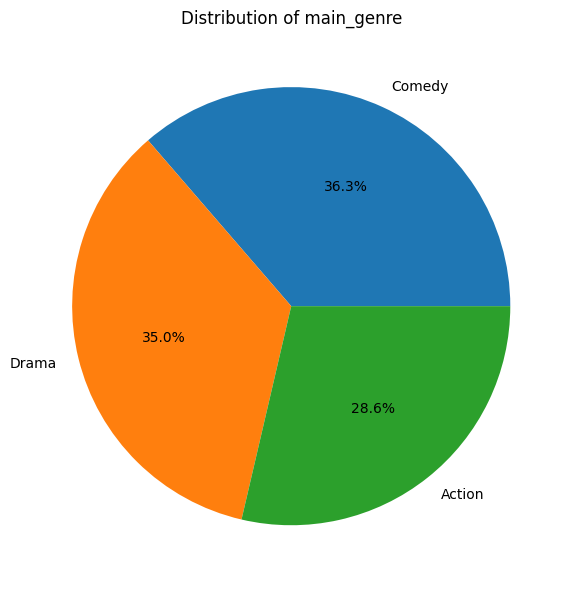

In [19]:
import matplotlib.pyplot as plt

# --- Choose the attribute/column to visualize ---
attribute = "main_genre"

# --- Count occurrences of each unique value ---
counts = df[attribute].value_counts()

# --- Plot pie chart ---
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title(f"Distribution of {attribute}")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


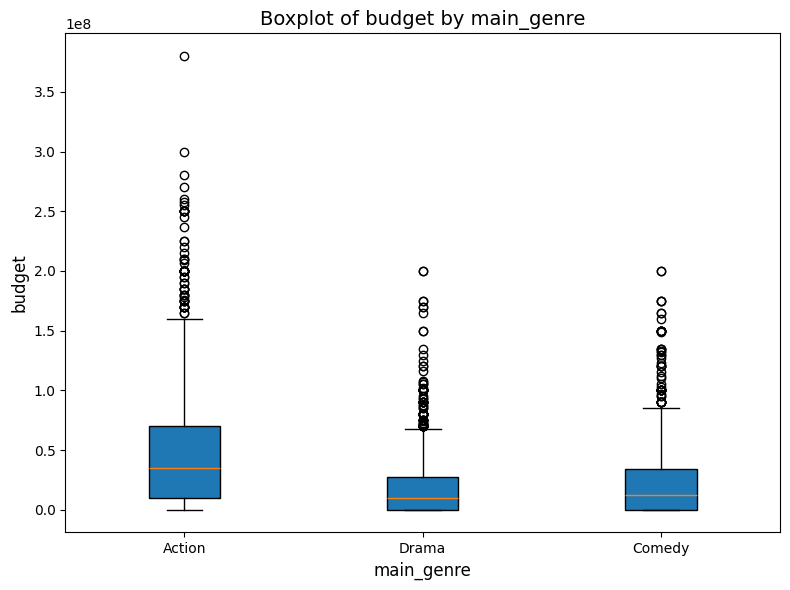

In [20]:
label_col = "main_genre"
numeric_feature = "budget"
box_plot_class(df, numeric_feature, label_col)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


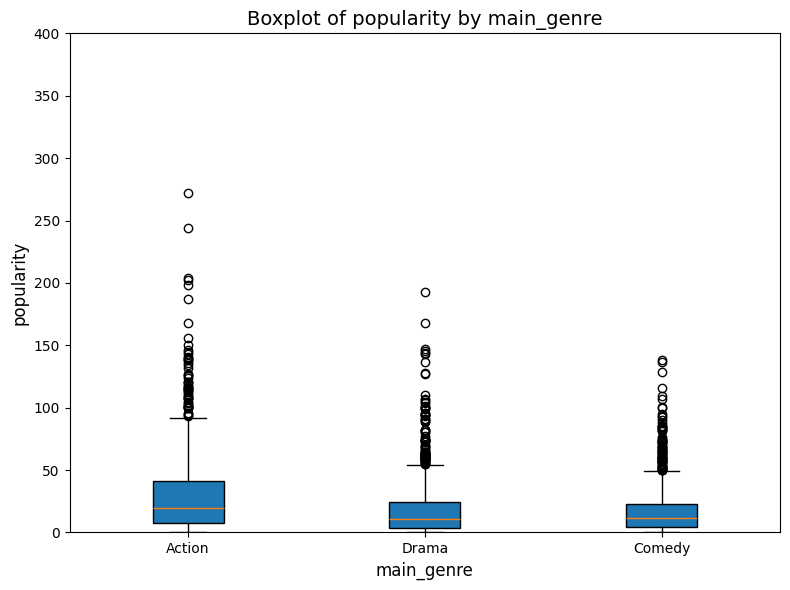

In [21]:
label_col = "main_genre"
numeric_feature = "popularity"
box_plot_class(df, numeric_feature, label_col, ylim=400)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


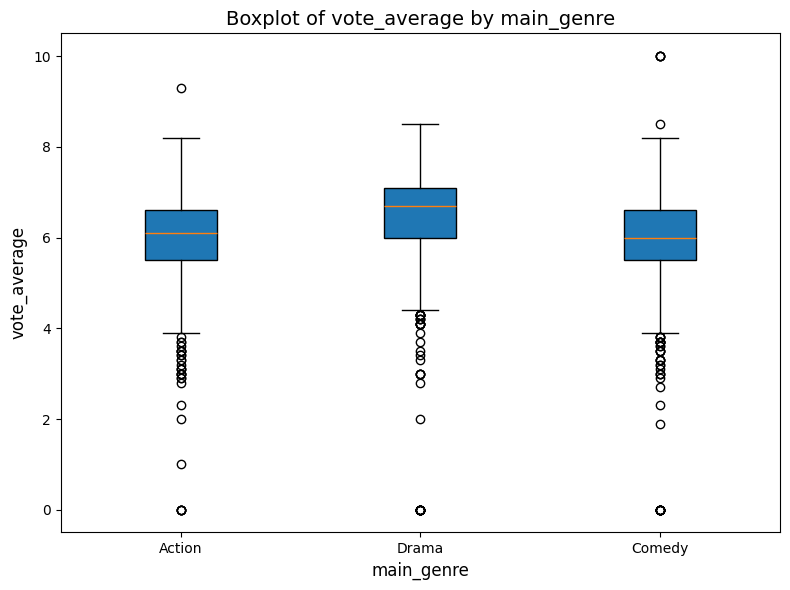

In [22]:
label_col = "main_genre"
numeric_feature = "vote_average"
box_plot_class(df, numeric_feature, label_col)

/tmp/ipython-input-3283231667.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_per_class, labels=class_labels, patch_artist=True)


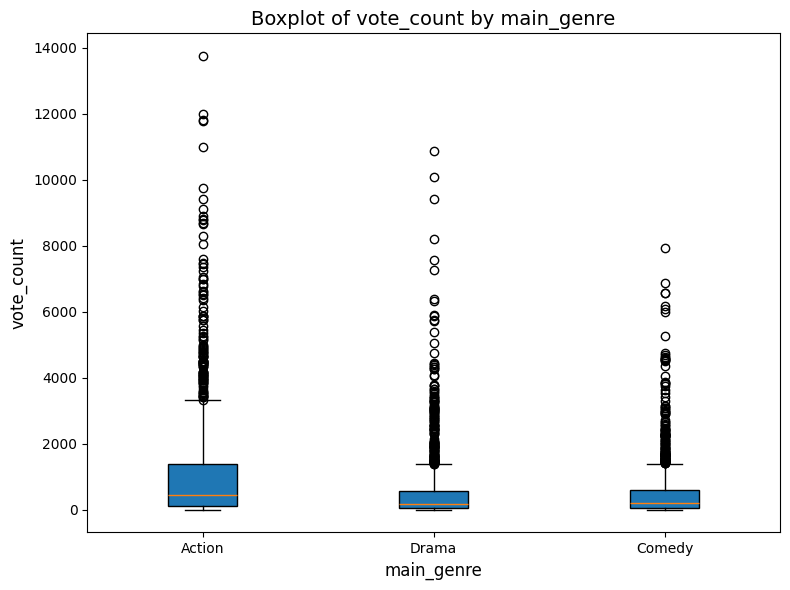

In [23]:
label_col = "main_genre"
numeric_feature = "vote_count"
box_plot_class(df, numeric_feature, label_col)

# 3. Classification Results

For our project, we have four classifiers: **Decision Tree**, **Naive Bayes**, **K-Nearest Neighbors (KNN)**, and **Random Forest**  

### Evaluation Method
To evaluate predictive performance, we used **10-fold cross-validation** for single classifiers (Decision Tree, Naive Bayes, KNN)
For Random Forest, we followed the requirement and used a **stratified split**:  
- 1/3 test set  
- 2/3 training + validation used to pick best trees  

For each model, we computed:  
- **Accuracy**  
- **Precision**  
- **Recall**  
- **F1 Score**

### Naive Bayes

Using 10-fold cross-validation, we found:

- Accuracy: ~0.5031
- Precision: ~0.4733
- Recall: ~0.0192
- F1: ~0.0216

### K-Nearest Neighbors (KNN)

Using 10-fold cross-validation, we found:

- Accuracy: ~0.565
- Precision: ~ 0.560
- Recall: ~0.029
- F1: ~0.029

### Decision Tree

Using 10-fold cross-validation, we found:

- Accuracy: ~0.478  
- Precision: ~0.488
- Recall: ~0.467
- F1: ~0.462

### Random Forest

We implemented our Random Forest using:

- N = 20 trees  
- M = 7 selected best trees  
- F = 2 random features per node  
- Stratified split (1/3 test, 2/3 remainder)

Performance:

- Accuracy: ~0.442
- Precision: ~0.497  
- Recall: ~0.422  
- F1 Score: ~0.387  

### Comparison


| Classifier       | Accuracy  |    Notes |
|------------------|-------------|-------|
| Decision Tree    | 0.4778      |  |
| Naive Bayes      | 0.5031      |  |
| KNN              | 0.5649     | The best,highest accuracy |
| Random Forest    | 0.4420     | The worst, loweset accuracy |

# 4. Conclusion

One of the biggest challenges with the dataset was choosing which genre to classify a film as, since there were multiple genres for one film. The genre of an instance was chosen arbitrarily as the first in its list of genres.

Each classifier performed around 50% accuracy supporting the inference from the exploratory data analysis of weak predictive power of numeric attributes.

Based on our results here, it seems that numeric features alone are not enough to accurately predict the genre of a film.

The things we change after presentation:
- We change the way we clean the dataset, at first we have four main genres: **Action**, **Comedy**, **Drama** and **other**. After we run the classifiers we find out that our accuray is very low. And we get some suggestion during our presentation, so we change the genres and made it as three, remove the **other**
- We change the **Random Forest** into *random stratified*, at first we didn't follow the requirement and we used **10-fold cross-validation** for **Random Forest** and I believe this is wong. So we follow the step of the requirement and fixed that. After that we found out that the accurary is increasing